# Análisis exploratorio del conjunto de datos de partidas de ajedrez 2016_CvC

Este cuaderno carga el archivo `chessdataset.csv`, examina los datos, resume los campos relevantes y genera un histograma, un diagrama de dispersión y diagramas de caja.

> **Discrepancia en el conjunto de datos:** el archivo adjunto contiene datos de partidas de ajedrez (48.871 filas y 20 columnas).





**EXPLICACION DEL JUEGO PARA PODER ENTENDER LO QUE SE ANALIZA**

# Entender la duración de la partida: *plies* frente a movimientos completos

Los datos y motores informáticos de ajedrez registran la duración de las partidas utilizando una terminología específica:

### *Ply* (o semimovimiento)

Un **ply** es un único movimiento realizado por un jugador, ya sean las blancas o las negras.

> **Ejemplo:** Que las blancas avancen un peón cuenta como **1 ply**.

### Movimiento completo

Un **movimiento completo** consiste en un par de turnos: un movimiento de las blancas seguido de un movimiento de las negras.

Por lo tanto:

- **1 movimiento completo = 2 plies**
- **10 movimientos completos = 20 plies**
- **50 movimientos completos = 100 plies**

---

# ¿Qué es el sistema de puntuación Elo?

El **sistema de puntuación Elo** es un método utilizado para calcular el **nivel de habilidad relativa de los jugadores** en juegos de suma cero, como el ajedrez.

Recibe su nombre de su creador, **Arpad Elo**, profesor de física y maestro de ajedrez húngaro-estadounidense.

A diferencia de los sistemas de puntos simples, en los que se obtiene una cantidad fija de puntos por victoria, el Elo se autorregula y se basa en **probabilidades**:

### Mide la habilidad relativa, no los puntos acumulados

Tu puntuación sube o baja en función de la **habilidad de tu oponente**, no solamente de si ganas o pierdes.

La puntuación Elo es una métrica estandarizada que se utiliza para cuantificar el **nivel de habilidad relativa** de un jugador.

### Puntuación más alta = jugador más fuerte

Estadísticamente, se espera que un jugador con una puntuación Elo más alta tenga un mejor desempeño que un oponente con una puntuación más baja, por lo que si tu le ganas a ese oponente de elo alto , se te agregan muchos puntos de Elo y si pierdes te bajan  poco Elo, en caso contrario , si pierdes con alguien de Elo muy bajo , se te bajaran mas cantidad de puntos de Elo y si ganas no te subiran tantos

### Niveles de habilidad

| Puntuación Elo         | Nivel aproximado                                           |
| ---------------------- | ---------------------------------------------------------- |
| **Por debajo de 1200** | Jugadores aficionados o principiantes                      |
| **1200–1800**          | Jugadores de nivel intermedio a fuerte / jugadores de club |
| **2000–2200**          | Candidatos a maestro y expertos                            |
| **2200–2400**          | Maestros nacionales e internacionales                      |
| **2500+**              | Grandes maestros (élite del ajedrez profesional)           |


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt



In [ ]:

DATA_PATH = "chessdataset.csv"


df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns from {DATA_PATH}")
print("\nColumn names:")
print(df.columns.tolist())
df.head()

Loaded 48,871 rows and 20 columns from chessdataset.csv

Column names:
['Game', 'White', 'Black', 'White Elo', 'Black Elo', 'White RD', 'Black RD', 'WhiteIsComp', 'BlackIsComp', 'TimeControl', 'Date', 'Time', 'White Clock', 'Black Clock', 'ECO', 'PlyCount', 'Result', 'Result-Winner', 'Commentaries', 'Moves']


,Game,White,Black,White Elo,Black Elo,White RD,Black RD,WhiteIsComp,BlackIsComp,TimeControl,Date,Time,White Clock,Black Clock,ECO,PlyCount,Result,Result-Winner,Commentaries,Moves
0,"""zerowin"" vs ""GeidiPrime""",zerowin,GeidiPrime,2848,2464,0.0,0.0,Yes,Yes,900+0,2016.12.31,23:17:00,15:00.0,15:00.0,A30,72,1/2-1/2,Draw,Game drawn by mutual agreement,1. c4 c5 2. Nf3 e6 3. g3 b6 4. Bg2 Bb7 5. O-O ...
1,"""GeidiPrime"" vs ""SlowBox""",GeidiPrime,SlowBox,2455,2511,0.0,0.0,Yes,Yes,900+0,2016.12.31,20:25:00,15:00.0,15:00.0,D01,127,1-0,White,Black checkmated,1. d4 Nf6 2. Nc3 d5 3. Bg5 Nbd7 4. Nf3 h6 5. B...
2,"""zerowin"" vs ""GeidiPrime""",zerowin,GeidiPrime,2846,2457,0.0,0.0,Yes,Yes,900+0,2016.12.31,20:03:00,15:00.0,15:00.0,A40,77,1-0,White,Black resigns,1. d4 e6 2. c4 Bb4+ 3. Bd2 Bxd2+ 4. Qxd2 Nf6 5...
3,"""GeidiPrime"" vs ""zerowin""",GeidiPrime,zerowin,2459,2844,0.0,0.0,Yes,Yes,900+0,2016.12.31,19:25:00,15:00.0,15:00.0,C11,128,0-1,Black,White resigns,1. d4 Nf6 2. Nc3 d5 3. Bg5 e6 4. e4 dxe4 5. Nx...
4,"""FishTest"" vs ""GeidiPrime""",FishTest,GeidiPrime,3033,2459,0.0,0.0,Yes,Yes,900+0,2016.12.31,18:42:00,15:00.0,15:00.0,C07,131,1-0,White,Black resigns,1. e4 e6 2. d4 d5 3. Nd2 c5 4. exd5 Qxd5 5. dx...


## 2. Comprobar la calidad de los datos y entender las columnas

Antes del análisis, verificamos si existen valores faltantes o filas exactamente duplicadas. También procesamos de que fecha a que fecha esta basado el dataset, y observamos las columnas y sus respectivos tipos

In [5]:
print("Data types:")
print(df.dtypes)
print("\nMissing values by column:")
print(df.isna().sum().sort_values(ascending=False))
print(f"\nExact duplicate rows: {df.duplicated().sum():,}")

# Convert the date text (for example, 2016.12.31) into pandas datetime values.
df["Date"] = pd.to_datetime(df["Date"], format="%Y.%m.%d", errors="coerce")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")

Data types:
Game                 str
White                str
Black                str
White Elo          int64
Black Elo          int64
White RD         float64
Black RD         float64
WhiteIsComp          str
BlackIsComp          str
TimeControl          str
Date                 str
Time                 str
White Clock          str
Black Clock          str
ECO                  str
PlyCount           int64
Result               str
Result-Winner        str
Commentaries         str
Moves                str
dtype: object

Missing values by column:
Game             0
White            0
Black            0
White Elo        0
Black Elo        0
White RD         0
Black RD         0
WhiteIsComp      0
BlackIsComp      0
TimeControl      0
Date             0
Time             0
White Clock      0
Black Clock      0
ECO              0
PlyCount         0
Result           0
Result-Winner    0
Commentaries     0
Moves            0
dtype: int64

Exact duplicate rows: 0
Date range: 2010-10-15 to 201

## 3. Resumen numérico y resultados de las partidas

La tabla descriptiva presenta el recuento, la media, la desviación estándar, los cuartiles y el rango. Los recuentos de resultados indican con qué frecuencia las partidas finalizaron con victoria de las blancas, victoria de las negras o tablas.

In [6]:
numeric_cols = ["White Elo", "Black Elo", "White RD", "Black RD", "PlyCount"]
print("Descriptive statistics:")
print(df[numeric_cols].describe().round(2))

print("\nGame outcomes:")
print(df["Result-Winner"].value_counts(dropna=False))

Descriptive statistics:
       White Elo  Black Elo  White RD  Black RD  PlyCount
count   48871.00   48871.00  48871.00  48871.00  48871.00
mean     2533.10    2534.36     37.26     37.18    123.75
std       295.78     293.92     21.28     20.93     59.45
min       818.00     831.00      0.00      0.00      0.00
25%      2334.00    2338.00     25.70     25.70     82.00
50%      2492.00    2496.00     32.90     33.00    117.00
75%      2759.00    2759.00     43.00     43.00    152.00
max      3308.00    3315.00    350.00    350.00    575.00

Game outcomes:
Result-Winner
White    21136
Black    18119
Draw      9616
Name: count, dtype: int64


## 4. Histograma: distribución de las puntuaciones Elo de los jugadores
El objetivo es comparar la frecuencia con la que los jugadores de distintos rangos de Elo utilizan piezas blancas y negras, con el fin de evaluar si existe algún tipo de sesgo o asimetría en la distribución de los colores según el nivel de habilidad.

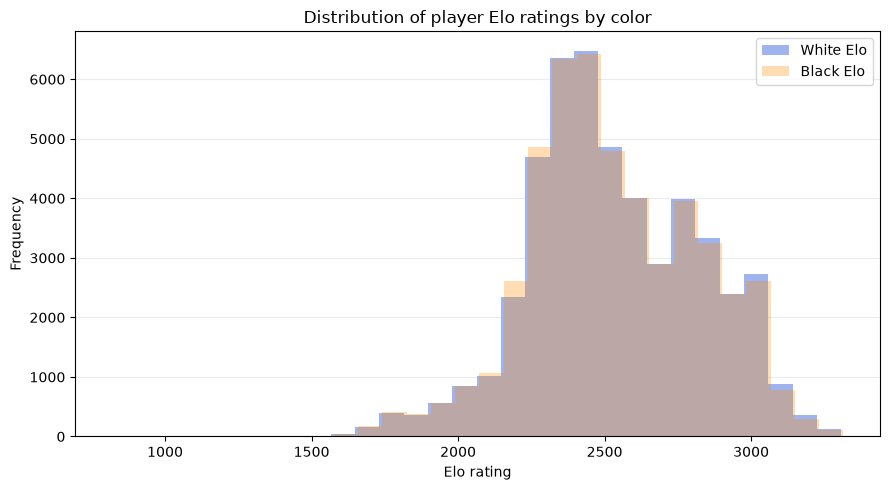

In [14]:
plt.figure(figsize=(9, 5))
plt.hist(df["White Elo"], bins=30, alpha=0.5, label="White Elo", color="royalblue")
plt.hist(df["Black Elo"], bins=30, alpha=0.3, label="Black Elo", color="darkorange")
plt.title("Distribution of player Elo ratings by color")
plt.xlabel("Elo rating")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### Conclusiones del Conjunto de Datos (Análisis de Elo)

*   **Ausencia de sesgo de Elo según el color:** Las distribuciones de Elo de los jugadores que conducen las blancas y las negras son prácticamente idénticas. Esto confirma que la asignación de colores es **equitativa y aleatoria**, eliminando cualquier favoratismo sistemático hacia los jugadores con mayor puntuación.
*   **Grupo de jugadores de alto nivel:** Los valores de Elo se concentran mayoritariamente entre **2200 y 2600**, alcanzando su punto máximo en el rango de **2400–2500**. Esto demuestra que el conjunto de datos está compuesto principalmente por partidas de nivel **Maestro y Gran Maestro**.


In [11]:
gropuby= df.groupby("Result-Winner")
gropuby.groups

{'Black': [3, 5, 6, 7, 9, 12, 16, 19, 24, 26, 29, 30, 33, 34, 39, 44, 47, 48, 50, 52, 54, 56, 60, 62, 64, 67, 70, 77, 79, 83, 85, 88, 89, 91, 92, 94, 101, 102, 106, 108, 111, 113, 115, 117, 120, 125, 128, 130, 131, 135, 138, 140, 143, 145, 147, 149, 151, 155, 159, 162, 163, 164, 167, 168, 170, 173, 175, 176, 179, 181, 185, 187, 189, 192, 193, 194, 196, 198, 200, 201, 205, 208, 213, 215, 217, 220, 221, 224, 226, 228, 230, 232, 235, 238, 239, 242, 245, 247, 249, 250, ...], 'Draw': [0, 10, 13, 18, 20, 22, 23, 36, 37, 42, 46, 55, 66, 73, 78, 81, 98, 99, 103, 109, 110, 121, 122, 127, 132, 137, 146, 152, 154, 157, 158, 169, 183, 184, 190, 202, 206, 210, 211, 225, 234, 268, 272, 278, 305, 307, 308, 312, 313, 317, 325, 326, 332, 334, 336, 347, 349, 353, 361, 365, 370, 380, 383, 385, 405, 413, 422, 433, 448, 450, 458, 459, 460, 462, 463, 464, 479, 480, 483, 484, 485, 493, 496, 497, 504, 505, 508, 512, 521, 522, 529, 561, 563, 565, 568, 571, 573, 577, 579, 582, ...], 'White': [1, 2, 4, 8, 11, 14

## 5. Diagrama de dispersión: Elo de las blancas frente al Elo de las negras

En este diagrama se analiza  la correlacion entre quien gana (o si empatan) con el Elo que presenta cada jugador en dicha partida

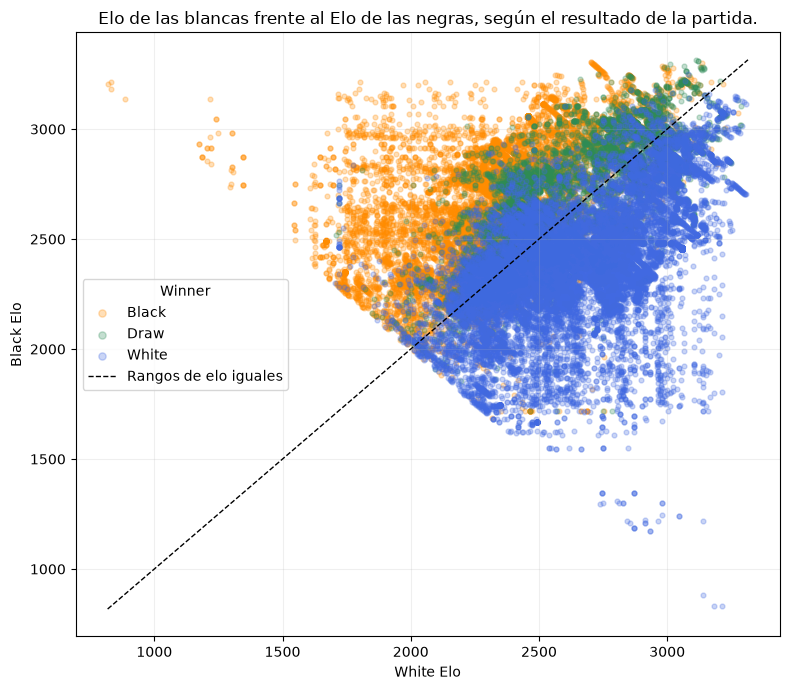

In [ ]:
colors = {"White": "royalblue", "Black": "darkorange", "Draw": "seagreen"}
plt.figure(figsize=(8, 7))
for outcome, group in df.groupby("Result-Winner", dropna=False):
    plt.scatter(
        group["White Elo"], group["Black Elo"],
        s=12, alpha=0.28, label=str(outcome),
        color=colors.get(outcome, "gray")
    )
lo = min(df["White Elo"].min(), df["Black Elo"].min())
hi = max(df["White Elo"].max(), df["Black Elo"].max())
plt.plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1, label="Rangos de Elo iguales")
plt.title("Elo de las blancas frente al Elo de las negras, según el resultado de la partida.")
plt.xlabel("White Elo")
plt.ylabel("Black Elo")
plt.legend(title="Winner", markerscale=1.5)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

####Conclusiones

### 1. La diferencia de Elo es el principal predictor del éxito
La ventaja de habilidad del jugador (un Elo más alto) es, con diferencia, el factor determinante más importante del resultado de la partida, eclipsando cualquier ventaja del color en enfrentamientos asimétricos.

*   **Por encima de la diagonal (y > x):** Cuando el Elo de las negras es notablemente superior al de las blancas, el gráfico está dominado por puntos naranjas (**victoria de las negras**).
*   **Por debajo de la diagonal (y < x):** Cuando el Elo de las blancas es superior al de las negras, el gráfico está dominado por puntos azules (**victoria de las blancas**).

### 2. Las tablas se concentran en los niveles de Elo más altos
Las partidas de gran nivel entre oponentes igualados suelen terminar en tablas, mientras que las partidas de niveles inferiores o con gran disparidad de Elo casi siempre tienen un resultado decisivo.

*   **Concentración en la élite:** Los puntos verdes (**tablas**) se agrupan densamente en el cuadrante superior derecho, donde ambos jugadores tienen un Elo superior a **2300** y están muy igualados a lo largo de la diagonal y = x.
*   **Ausencia en niveles inferiores:** Prácticamente no se producen tablas en niveles de Elo bajos o intermedios (por debajo de 2000) ni en partidas con grandes diferencias de Elo.

### 3. Ligera ventaja del primer movimiento (blancas)
Las blancas pueden superar una pequeña desventaja de Elo para ganar o empatar, lo que refleja la ventaja inherente de la iniciativa del primer movimiento en el ajedrez.

*   **Invasión blanca:** Los puntos azules (**victoria de las blancas**) se extienden ligeramente por encima de la línea discontinua de igualdad de Elo, adentrándose en zonas donde las negras tienen un Elo algo mayor.
*   **Contención negra:** Por el contrario, los puntos naranjas (**victoria de las negras**) rara vez cruzan por debajo de la línea y = x hacia zonas donde las blancas tienen un Elo superior.

### 4. Ausencia de sorpresas ante diferencias extremas de Elo
El nivel técnico absoluto elimina el factor azar cuando la brecha de habilidad es masiva.

*   **Resultados absolutos:** En la esquina inferior derecha (Elo de las blancas > 2800, Elo de las negras < 1500) y en la esquina superior izquierda, los resultados son decisivos en el **100% de los casos** a favor del jugador con mayor Elo.


## 6. Diagrama de caja y bigotes: duración de la partida según el resultado

Un **diagrama de caja** resume una distribución utilizando su mediana, los cuartiles inferior y superior, y los posibles valores atípicos. Comparamos la variable `PlyCount` (número de semimovimientos) para cada resultado de la partida. Esto permite observar si las partidas que terminan en tablas tienden a durar más que aquellas con un resultado decisivo.

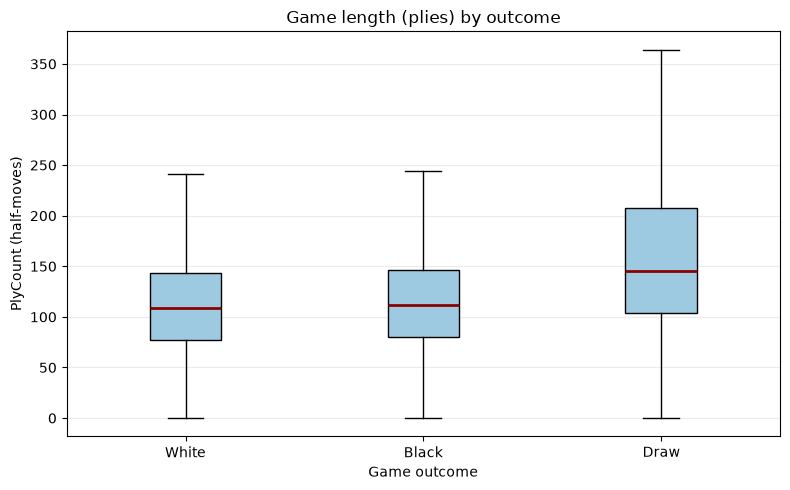

In [16]:
order = ["White", "Black", "Draw"]
box_data = [df.loc[df["Result-Winner"] == label, "PlyCount"].dropna() for label in order]
plt.figure(figsize=(8, 5))
plt.boxplot(box_data, tick_labels=order, showfliers=False, patch_artist=True,
            boxprops={"facecolor": "#9ecae1"}, medianprops={"color": "darkred", "linewidth": 2})
plt.title("Game length (plies) by outcome")
plt.xlabel("Game outcome")
plt.ylabel("PlyCount (half-moves)")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

##Conclusiones

#Las partidas que terminan en empate tienden a ser más largas, pero también pueden producirse en partidas relativamente breves. Su característica distintiva es la distribución mucho más amplia de la duración de las partidas.

#Aproximadamente la mitad de todos los juegos empatados tienen más de ~145 plies, mientras que alrededor del 75% de los juegos decisivos tienen menos de ~145 plies.

#La duración de las partidas decisivas parece ser, en gran medida, independiente de si ganan las blancas o las negras.

## 8. histograma de la duración de las partidas

Este histograma  ofrece una visión general de la distribución de la duración de las partidas. Resulta útil para identificar asimetrías y partidas inusualmente largas. El valor `PlyCount` se contabiliza en semimovimientos, no en turnos completos.

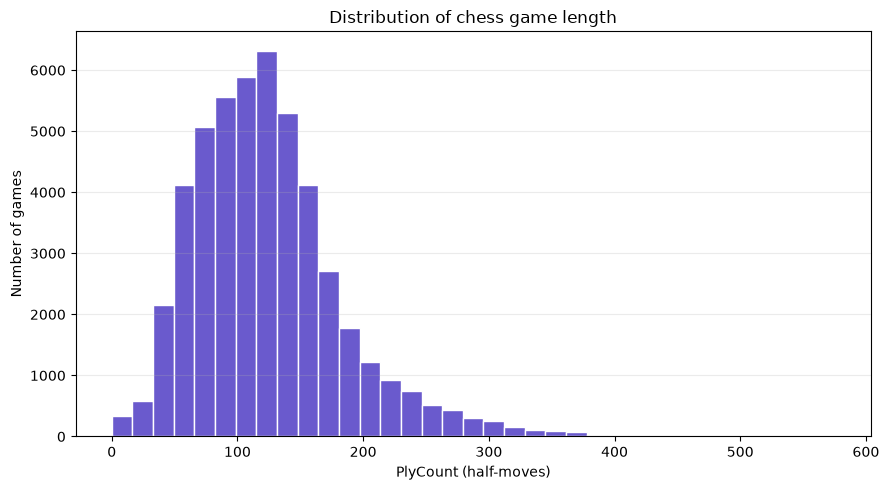

In [18]:
plt.figure(figsize=(9, 5))
plt.hist(df["PlyCount"].dropna(), bins=35, color="slateblue", edgecolor="white")
plt.title("Distribution of chess game length")
plt.xlabel("PlyCount (half-moves)")
plt.ylabel("Number of games")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

#Conclusiones

##Duración estándar de la partida: Una partida típica dura entre 70 y 160 semimovimientos (aproximadamente de 35 a 80 movimientos completos). Las partidas que superan los 300 semimovimientos constituyen casos estadísticos extremadamente atípicos.

##Las finalizaciones prematuras son poco frecuentes: muy pocas partidas concluyen en menos de 30 semimovimientos (aproximadamente 15 movimientos completos), lo que indica que las retiradas tempranas o los mates rápidos («miniaturas») son poco habituales.

##Distribución con sesgo a la derecha: La distribución presenta un marcado sesgo a la derecha (sesgo positivo). La frecuencia cae bruscamente por debajo de los 40 *plies*, pero disminuye gradualmente formando una larga cola que se extiende hasta aproximadamente 380 *plies* (unas 190 jugadas completas).